In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import make_moons, make_circles
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.preprocessing import StandardScaler

## 1. What is clustering?

Clustering is an **unsupervised learning** task.  
The goal is to group similar data points together.

A good clustering algorithm should place:
- similar points in the same cluster,
- dissimilar points in different clusters.

Different clustering algorithms use different ideas:

- **KMeans** uses cluster centers.
- **DBSCAN** uses density of points.
- **Agglomerative Clustering** builds clusters step by step in a hierarchy.

## 2. DBSCAN: intuition

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**.

Main idea:
- points in a dense region belong to the same cluster,
- isolated points are treated as **noise**.

### Important parameters

1. **eps**
   - maximum distance to consider another point as a neighbor

2. **min_samples**
   - minimum number of nearby points required to form a dense region

### Main advantages of DBSCAN

- does **not** require specifying the number of clusters in advance,
- can find clusters of **arbitrary shape**,
- can detect **noise/outliers**.

### Main limitations

- sensitive to the choice of `eps` and `min_samples`,
- may struggle when different clusters have very different densities.

### Types of points in DBSCAN

- **Core point**: has at least `min_samples` points in its neighborhood
- **Border point**: close to a core point but does not itself have enough neighbors
- **Noise point**: does not belong to any dense region

## 3. Create a synthetic dataset for DBSCAN

We will create:
- two moon-shaped clusters,
- some additional random noise points.

This is a good example because:
- KMeans usually prefers round clusters,
- DBSCAN can often handle curved shapes better,
- DBSCAN can also mark noisy points as outliers.

In [ ]:
# Create moon-shaped data
X_main, y_main = make_moons(n_samples=400, noise=0.06, random_state=42)

# Add random noise points
rng = np.random.RandomState(42)
X_noise = rng.uniform(low=[-1.5, -1.0], high=[2.5, 1.5], size=(60, 2))
y_noise = np.full(60, -1)

# Combine data
X_db = np.vstack([X_main, X_noise])
y_db_true = np.concatenate([y_main, y_noise])

# Scale features
scaler = StandardScaler()
X_db = scaler.fit_transform(X_db)

print("Shape of dataset:", X_db.shape)

Shape of dataset: (460, 2)


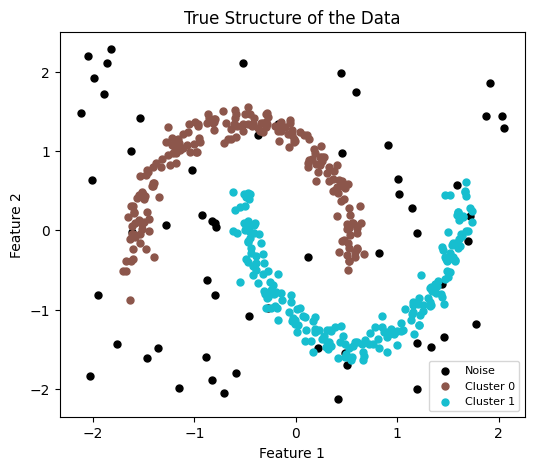

In [ ]:
def plot_clusters(X, labels, title, ax):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for color, label in zip(colors, unique_labels):
        if label == -1:
            color = "black"
            name = "Noise"
        else:
            name = f"Cluster {label}"

        ax.scatter(
            X[labels == label, 0],
            X[labels == label, 1],
            s=25,
            color=color,
            label=name
        )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc="best", fontsize=8)

fig, ax = plt.subplots(figsize=(6, 5))
plot_clusters(X_db, y_db_true, "True Structure of the Data", ax)
plt.show()

In [ ]:
dbscan_model = DBSCAN(eps=0.22, min_samples=5)
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
agg_model = AgglomerativeClustering(n_clusters=2, linkage="average")

y_dbscan = dbscan_model.fit_predict(X_db)
y_kmeans = kmeans_model.fit_predict(X_db)
y_agg = agg_model.fit_predict(X_db)

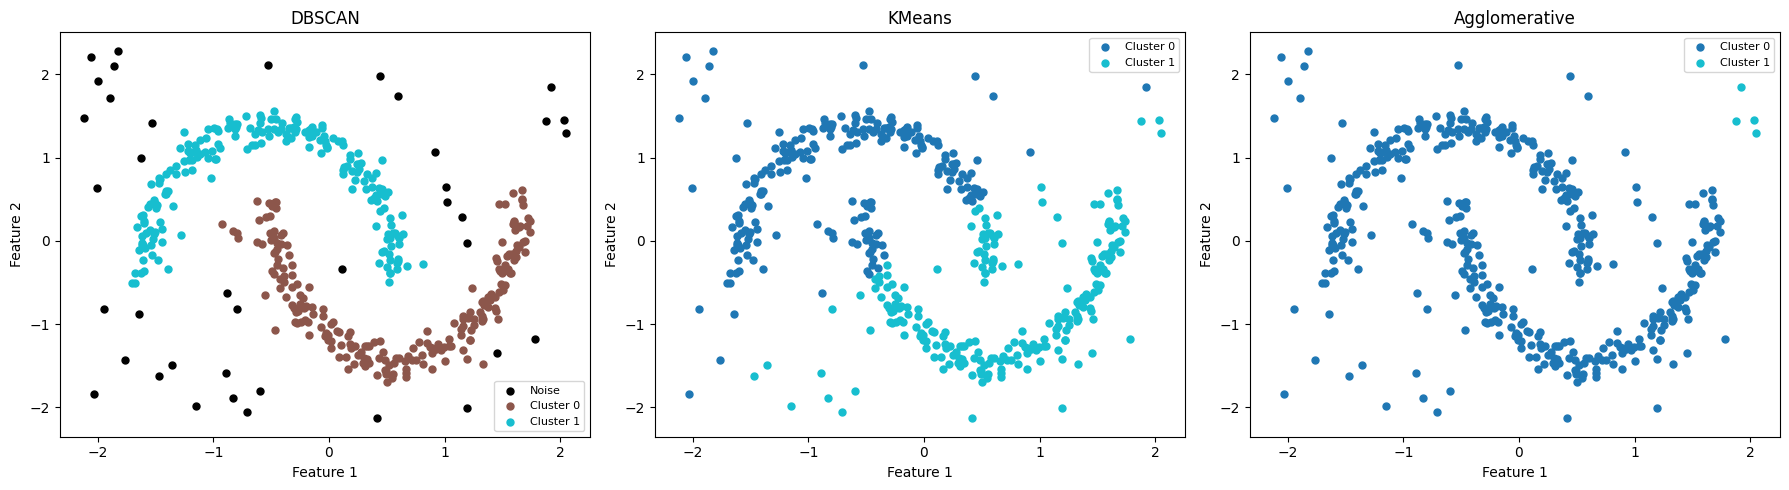

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_clusters(X_db, y_dbscan, "DBSCAN", axes[0])
plot_clusters(X_db, y_kmeans, "KMeans", axes[1])
plot_clusters(X_db, y_agg, "Agglomerative", axes[2])

plt.tight_layout()
plt.show()

## 5. Evaluation metrics for clustering

We use both **internal** and **external** metrics.

### Internal metrics
These use only the data and predicted clusters.

1. **Silhouette Score**
   - higher is better
   - measures how well separated the clusters are

2. **Davies-Bouldin Index**
   - lower is better
   - measures similarity between clusters

3. **Calinski-Harabasz Score**
   - higher is better
   - compares between-cluster separation and within-cluster compactness

### External metric
This compares predicted clusters with known labels.

4. **Adjusted Rand Index (ARI)**
   - higher is better
   - equals 1 for perfect clustering

### Important note for DBSCAN

DBSCAN may label some points as **-1** for noise.  
For internal metrics, we will compute scores only on the non-noise points.

In [ ]:
def evaluate_clustering(X, y_true, y_pred, model_name):
    result = {"Model": model_name}

    # Number of clusters found
    n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    result["Clusters found"] = n_clusters

    # Number of noise points
    result["Noise points"] = int(np.sum(y_pred == -1)) if -1 in y_pred else 0

    # For internal metrics, ignore noise points if present
    if -1 in y_pred:
        mask = y_pred != -1
        X_eval = X[mask]
        y_eval = y_pred[mask]
    else:
        X_eval = X
        y_eval = y_pred

    if len(X_eval) > 1 and len(np.unique(y_eval)) > 1:
        result["Silhouette"] = round(silhouette_score(X_eval, y_eval), 3)
        result["Davies-Bouldin"] = round(davies_bouldin_score(X_eval, y_eval), 3)
        result["Calinski-Harabasz"] = round(calinski_harabasz_score(X_eval, y_eval), 3)
    else:
        result["Silhouette"] = np.nan
        result["Davies-Bouldin"] = np.nan
        result["Calinski-Harabasz"] = np.nan

    # External metric
    result["ARI"] = round(adjusted_rand_score(y_true, y_pred), 3)

    return result

In [ ]:
results_db = pd.DataFrame([
    evaluate_clustering(X_db, y_db_true, y_dbscan, "DBSCAN"),
    evaluate_clustering(X_db, y_db_true, y_kmeans, "KMeans"),
    evaluate_clustering(X_db, y_db_true, y_agg, "Agglomerative")
])

results_db

,Model,Clusters found,Noise points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,DBSCAN,2,39,0.372,1.058,339.310,0.891
1,KMeans,2,0,0.463,0.880,500.464,0.364
2,Agglomerative,2,0,0.323,0.605,12.701,0.016


## 6. Interpretation of DBSCAN results

Typical observations:

- **DBSCAN** often performs well on curved clusters.
- It can identify noisy points explicitly.
- **KMeans** often struggles with non-spherical shapes.
- **Agglomerative Clustering** may do better than KMeans, but usually depends on the chosen linkage.

When the data contains:
- irregular shapes,
- outliers,
- unknown number of clusters,

DBSCAN is often a strong candidate.

## 7. Effect of changing `eps` in DBSCAN

`eps` is one of the most important parameters in DBSCAN.

- If `eps` is too small:
  - many points become noise
  - clusters may break apart

- If `eps` is too large:
  - different clusters may merge together

Let us see this visually.

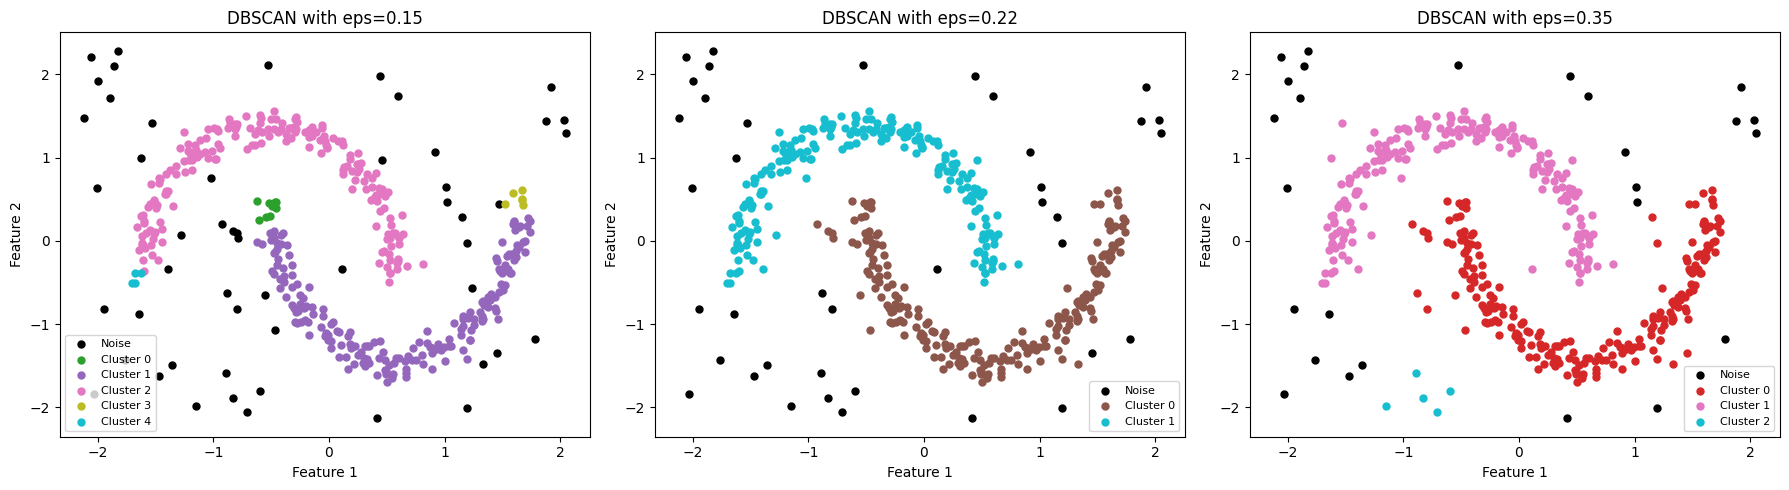

In [ ]:
eps_values = [0.15, 0.22, 0.35]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_db)
    plot_clusters(X_db, labels, f"DBSCAN with eps={eps}", ax)

plt.tight_layout()
plt.show()

## 8. Short summary of DBSCAN

DBSCAN is best when:

- the cluster shape is irregular,
- there are outliers/noise,
- we do not know the number of clusters beforehand.

DBSCAN is not ideal when:

- cluster densities differ a lot,
- parameter tuning is difficult,
- the dataset is high-dimensional and distance becomes less meaningful.

## 9. Agglomerative Clustering

Agglomerative Clustering is a **hierarchical clustering** method.

It works in a **bottom-up** way:

1. start with each point as its own cluster,
2. repeatedly merge the two closest clusters,
3. continue until the required number of clusters is reached.

### Important parameters

1. **n_clusters**
   - number of clusters to form

2. **linkage**
   - how distance between clusters is defined

Common linkage options:
- **ward**
- **complete**
- **average**
- **single**

### Meaning of linkage

- **single**: minimum distance between two clusters
- **complete**: maximum distance between two clusters
- **average**: average pairwise distance
- **ward**: merges clusters to minimize variance increase

### Strengths

- simple and interpretable,
- no random initialization,
- can capture hierarchical structure.

### Limitations

- usually needs `n_clusters` in advance,
- can become expensive for large datasets,
- result depends strongly on the linkage method.

## 10. Create a dataset for Agglomerative Clustering

We use concentric circles.

This is useful because:
- KMeans usually prefers round blobs separated by centers,
- hierarchical clustering with suitable linkage can sometimes capture this structure better.

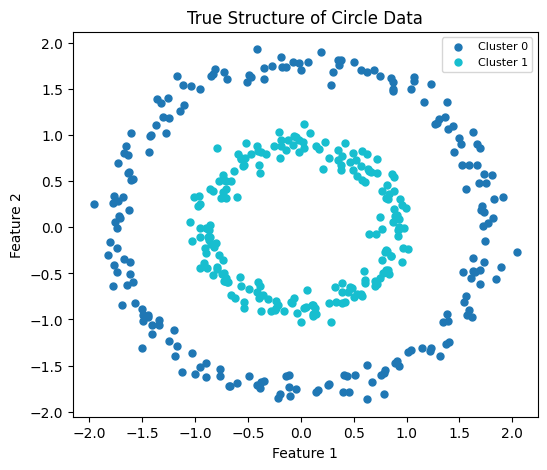

In [ ]:
X_ag, y_ag_true = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)

scaler = StandardScaler()
X_ag = scaler.fit_transform(X_ag)

fig, ax = plt.subplots(figsize=(6, 5))
plot_clusters(X_ag, y_ag_true, "True Structure of Circle Data", ax)
plt.show()

In [ ]:
agg_single = AgglomerativeClustering(n_clusters=2, linkage="single")
kmeans_circle = KMeans(n_clusters=2, random_state=42, n_init=10)

y_agg_single = agg_single.fit_predict(X_ag)
y_kmeans_circle = kmeans_circle.fit_predict(X_ag)

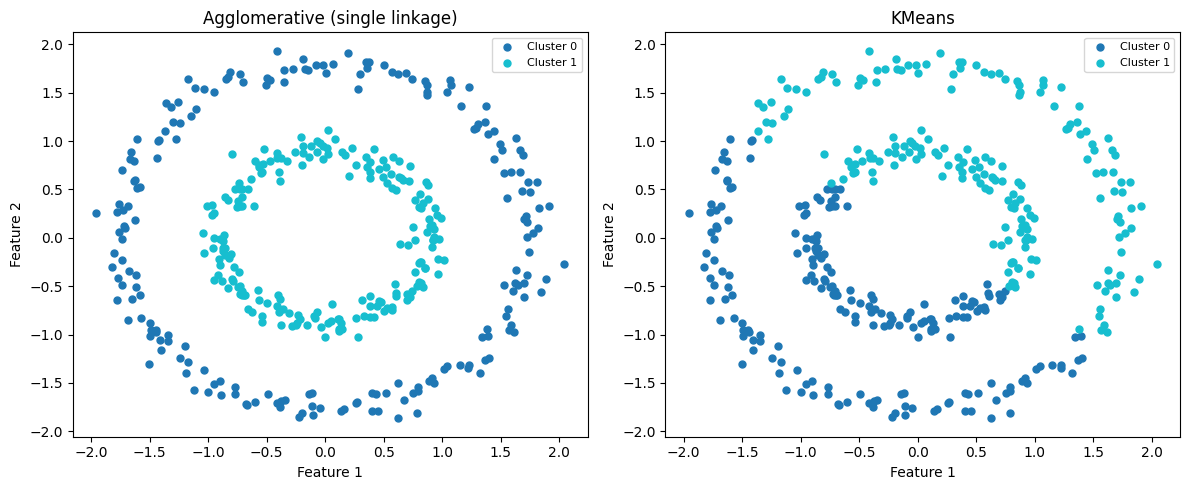

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_clusters(X_ag, y_agg_single, "Agglomerative (single linkage)", axes[0])
plot_clusters(X_ag, y_kmeans_circle, "KMeans", axes[1])

plt.tight_layout()
plt.show()

In [ ]:
results_ag = pd.DataFrame([
    evaluate_clustering(X_ag, y_ag_true, y_agg_single, "Agglomerative (single)"),
    evaluate_clustering(X_ag, y_ag_true, y_kmeans_circle, "KMeans")
])

results_ag

,Model,Clusters found,Noise points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,Agglomerative (single),2,0,0.111,331.956,0.003,1.000
1,KMeans,2,0,0.354,1.176,232.477,-0.002


## 12. Compare different linkage methods

**Agglomerative Clustering is not one single behavior**.

The linkage choice can change the result significantly.

In [ ]:
linkages = ["ward", "complete", "average", "single"]

rows = []

for linkage in linkages:
    model = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    labels = model.fit_predict(X_ag)
    rows.append(evaluate_clustering(X_ag, y_ag_true, labels, f"Agglomerative ({linkage})"))

linkage_results = pd.DataFrame(rows)
linkage_results

,Model,Clusters found,Noise points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,Agglomerative (ward),2,0,0.333,1.204,210.165,0.020
1,Agglomerative (complete),2,0,0.347,1.199,223.150,-0.002
2,Agglomerative (average),2,0,0.348,1.179,225.404,-0.002
3,Agglomerative (single),2,0,0.111,331.956,0.003,1.000


**Single linkage:**
ARI = 1, meaning it matches the true labels perfectly. However, the internal metrics—Silhouette = 0.111, Davies-Bouldin = 331.956, and Calinski-Harabasz = 0.003—show that the clusters are geometrically poor. This happens because single linkage connects points based on the closest distance, forming long, chain-like clusters. While the labels are correctly assigned, the clusters themselves are not tight or well-separated.

**Ward, Complete, and Average linkages:**
These methods produce more compact clusters with Silhouette ≈ 0.33–0.35, Davies-Bouldin ≈ 1.18–1.20, and Calinski-Harabasz ≈ 210–225, indicating moderate cohesion and reasonable separation. However, their ARI values are close to zero, meaning the clusters do not match the true labels. This occurs because these linkages prioritize compactness and cluster shape over label recovery; the clusters look geometrically “good” but do not reflect the actual groupings in the data.

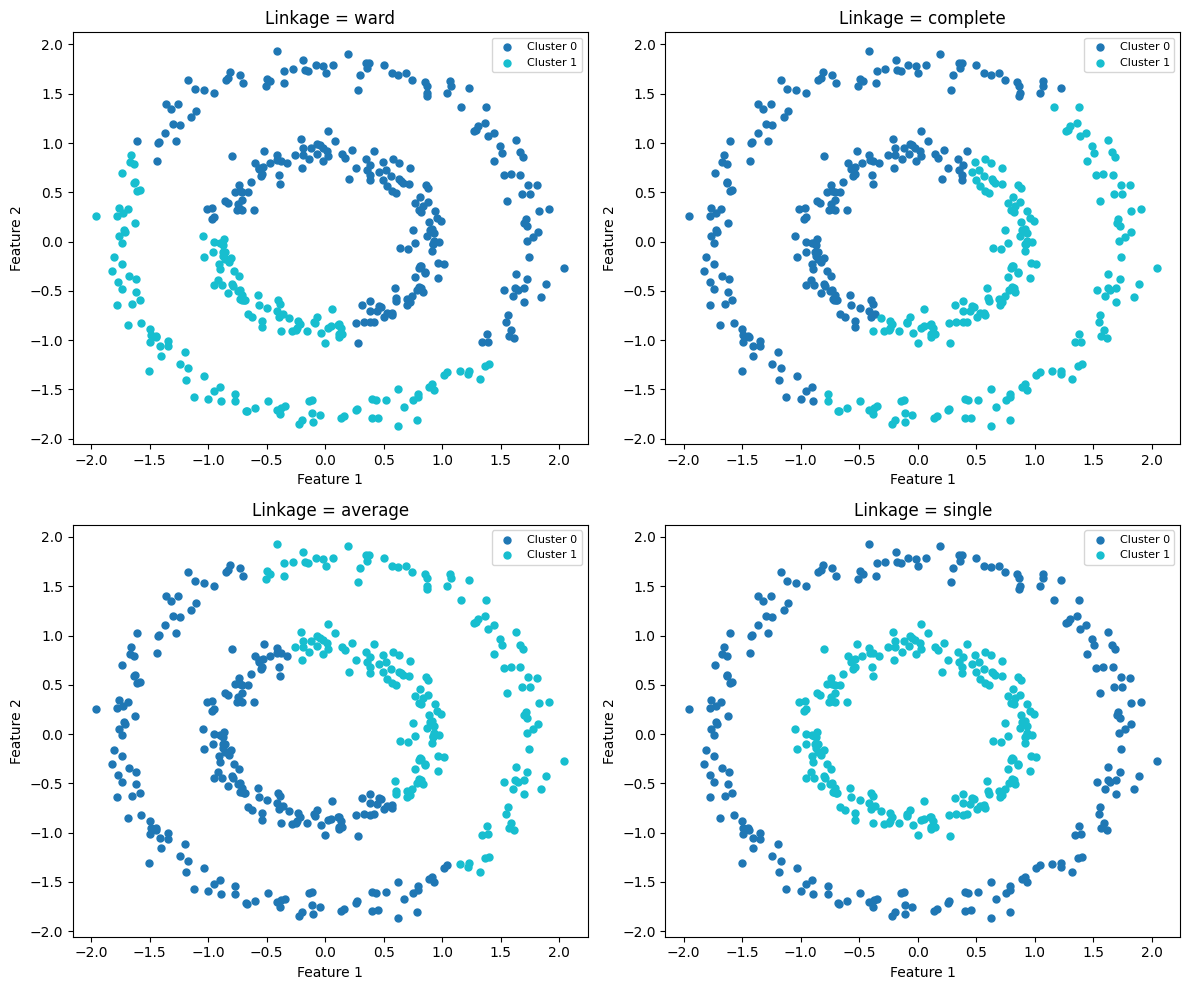

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, linkage in zip(axes.ravel(), linkages):
    model = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    labels = model.fit_predict(X_ag)
    plot_clusters(X_ag, labels, f"Linkage = {linkage}", ax)

plt.tight_layout()
plt.show()

## 13. Observations for Agglomerative Clustering

Important points:

- Agglomerative Clustering builds clusters step by step.
- The choice of linkage matters a lot.
- On non-convex shapes, some linkage types may perform much better than KMeans.
- Ward linkage is often good for compact, spherical clusters.
- Single linkage can handle connected shapes better, but can be sensitive to chaining.

## 14. Overall comparison: DBSCAN vs Agglomerative vs KMeans

### KMeans
Best when:
- clusters are roughly spherical,
- number of clusters is known,
- data has low noise.

### DBSCAN
Best when:
- cluster shape is irregular,
- there are outliers,
- number of clusters is unknown.

### Agglomerative Clustering
Best when:
- hierarchical relationships are meaningful,
- dataset size is not too large,
- we want to study the effect of different linkage rules.

In [ ]:
summary = pd.concat(
    [results_db.assign(Experiment="DBSCAN dataset"),
     results_ag.assign(Experiment="Agglomerative dataset")],
    ignore_index=True
)

summary

,Model,Clusters found,Noise points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,Experiment
0,DBSCAN,2,39,0.372,1.058,339.310,0.891,DBSCAN dataset
1,KMeans,2,0,0.463,0.880,500.464,0.364,DBSCAN dataset
2,Agglomerative,2,0,0.323,0.605,12.701,0.016,DBSCAN dataset
3,Agglomerative (single),2,0,0.111,331.956,0.003,1.000,Agglomerative dataset
4,KMeans,2,0,0.354,1.176,232.477,-0.002,Agglomerative dataset
